In [1]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%load_ext autoreload

### Housekeeping

In [2]:
def get_dataframe_from_log_folder(root : str):
    metric_files = glob.glob(os.path.join(root, "*", "metrics.jsonl"))

    metric_dfs = []

    for metric_file in metric_files:
        short_path = metric_file.split("/logs/")[-1]
        run_name = short_path.split("/")[0]
        
        metric_df = pd.read_json(metric_file, lines=True)
        metric_df["run_name"] = run_name
        metric_dfs.append(metric_df)

    metric_df = pd.concat(metric_dfs, ignore_index=True)
    return metric_df

def filter_columns_by_regex(df, regex, drop_na : bool = False):
    regex = f"({regex}|run_name)"
    df = df.set_index("step").filter(regex=regex)
    if drop_na:
        df = df.dropna(axis=0, how="any")
    return df


In [3]:
ROOT = os.path.abspath(os.path.join("..", 'logs'))

metrics = get_dataframe_from_log_folder(ROOT)

In [20]:
def plot_ema_metrics(metrics_df, regex, span=10, drop_na=True):
    metrics = filter_columns_by_regex(metrics_df, regex, drop_na=drop_na)

    # Calculate EMA for each column except 'run_name'
    ema_metrics = metrics.copy()
    for col in ema_metrics.columns:
        if col != 'run_name':
            ema_metrics[col] = metrics[col].ewm(span=span, adjust=False).mean()

    # Plot the EMA data on a two-column graph
    num_cols = len([col for col in ema_metrics.columns if col != 'run_name'])
    fig, axes = plt.subplots(nrows=(num_cols + 1) // 2, ncols=2, figsize=(20, 40))

    i = 0
    for col in ema_metrics.columns:
        if col != 'run_name':
            ax = axes[i // 2, i % 2]
            for run_name in ema_metrics['run_name'].unique():
                run_data = ema_metrics[ema_metrics['run_name'] == run_name]
                ax.plot(run_data.index, run_data[col], label=run_name)

            ax.set_xlabel('Step')
            ax.set_ylabel(col)
            ax.set_title(f'Step vs {col} (EMA)')
            ax.legend()
            i += 1

    plt.tight_layout()
    plt.show()


### Achievements

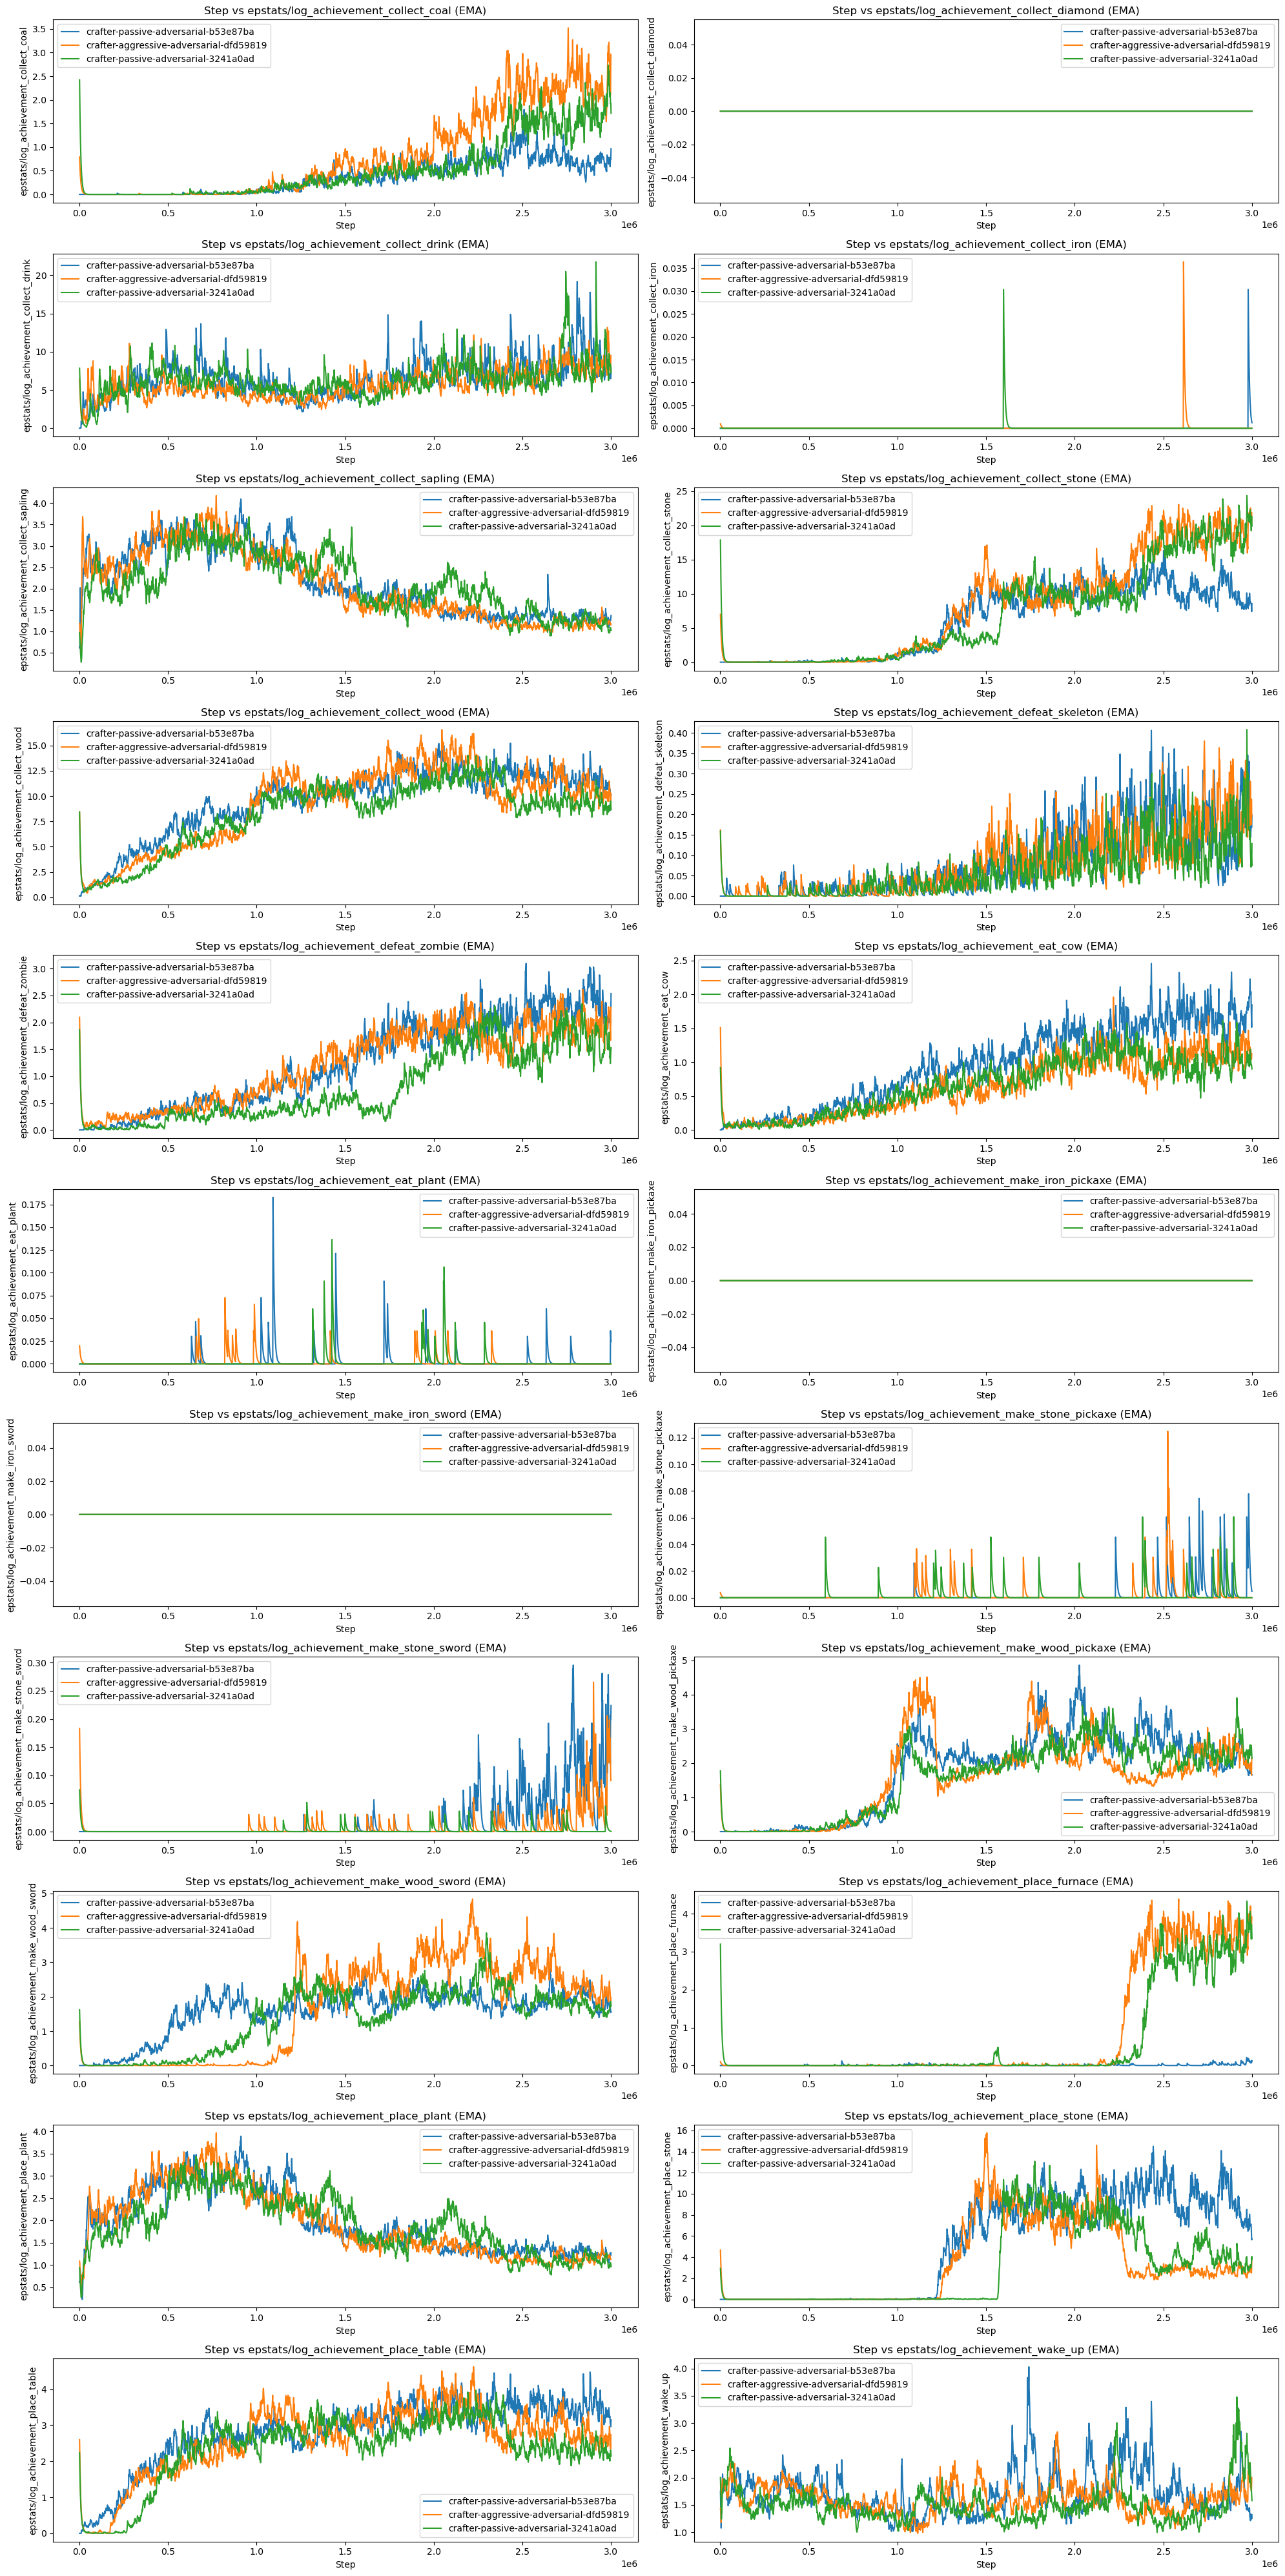

In [23]:
plot_ema_metrics(metrics, r"epstats/log_achievement_[a-z_]+$", span=10, drop_na=True)

### Loss

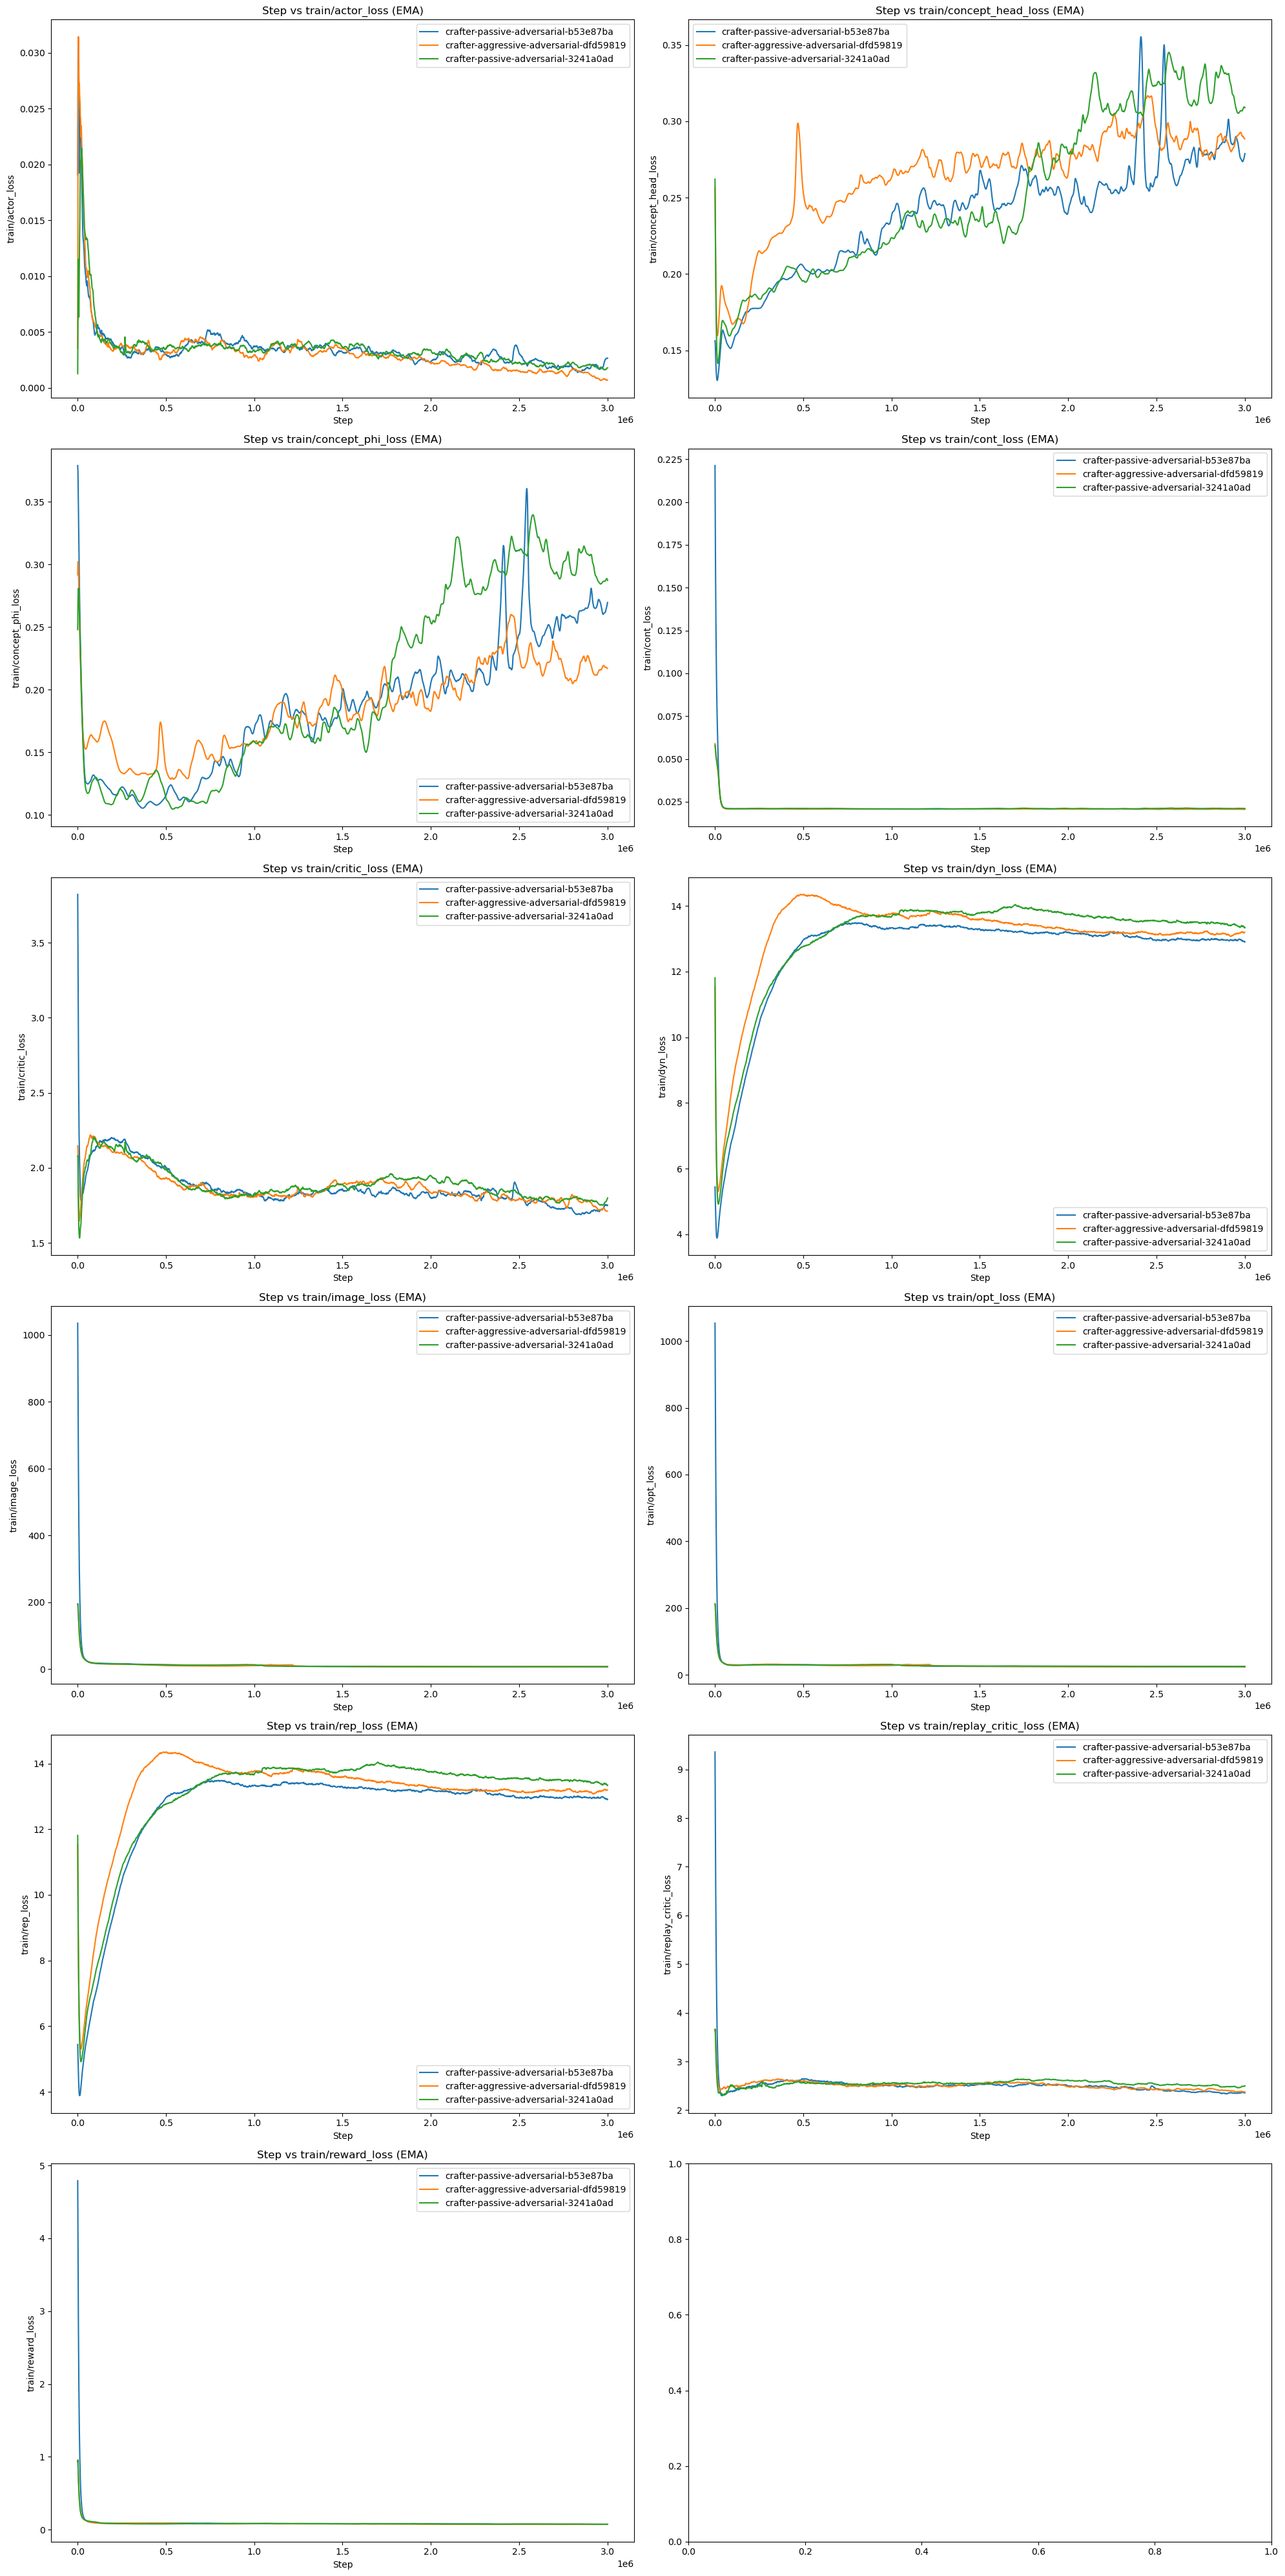

In [ ]:

# Example usage
plot_ema_metrics(metrics, r"train/[a-z_]+_loss$")